# Challenge 7 — Time Series Detective

**Nombre:** Abigail Chirinos Espejel
**Clase:** Series Temporales I 

__Objetivo:__ Detectar tendencia, estacionalidad, dependencia temporal y posibles problemas de estacionalidad.
 **Challenge:** 

La dirección de la empresa afirma:

> **“Las ventas están creciendo y presentan un patrón semanal.”**

Vamos a revisar si los datos respaldan esta afirmación usando la serie de ventas de `ventas_tienda.csv`.


## 1. Preparar la serie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ventas_tienda.csv")

df["fecha"] = pd.to_datetime(df["fecha"])

df = df.sort_values("fecha")
df = df.set_index("fecha")

serie = df["ventas"]

serie.head()

fecha
2025-01-01    41.21
2025-01-02    51.73
2025-01-03    51.06
2025-01-04    49.62
2025-01-05    42.36
Name: ventas, dtype: float64

## Paso 2. Auditoría temporal

In [2]:
print("Primera fecha:", serie.index.min())
print("Última fecha:", serie.index.max())
print("Número de observaciones:", len(serie))

fechas_esperadas = pd.date_range(serie.index.min(),serie.index.max(),freq="D")
fechas_faltantes = fechas_esperadas.difference(serie.index)

print("Días faltantes:", len(fechas_faltantes))
print("Fechas faltantes:")
print(fechas_faltantes)

Primera fecha: 2025-01-01 00:00:00
Última fecha: 2025-12-31 00:00:00
Número de observaciones: 359
Días faltantes: 6
Fechas faltantes:
DatetimeIndex(['2025-02-06', '2025-03-05', '2025-04-08', '2025-06-26',
               '2025-08-16', '2025-12-04'],
              dtype='datetime64[us]', freq=None)


Se revisan las fechas para detectar huecos en la serie. Esto es importante antes de analizar tendencias y patrones temporales.


## 3. Gráfica de las ventas

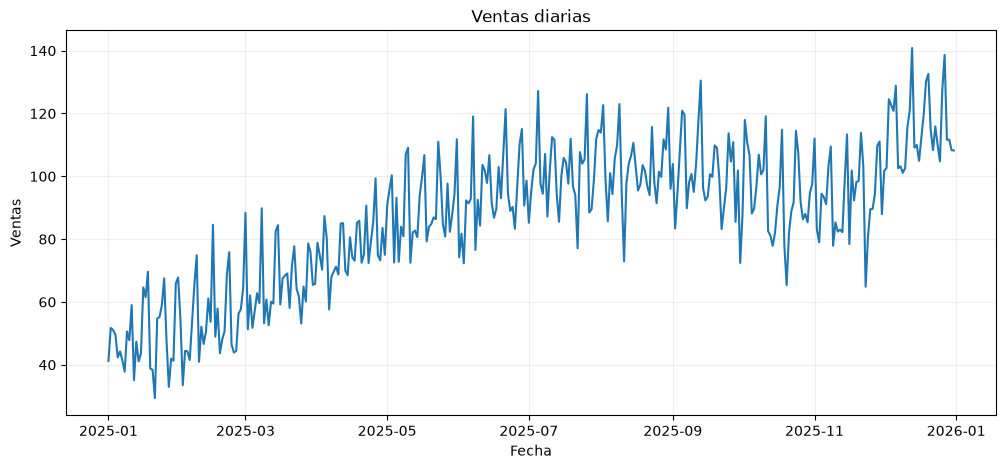

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(serie)
plt.title("Ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.2)
plt.show()

### Observación

En la gráfica podemos observar diferenctes cambios y que existen estacionalidad, pero aún no se puede afirmar nada.


## 4. Resampling semanal y mensual

In [4]:
serie_semanal = serie.resample("W").sum()
serie_mensual = serie.resample("ME").sum()

print("Ventas semanales:")
display(serie_semanal.head())

print("Ventas mensuales:")
display(serie_mensual)

Ventas semanales:


fecha
2025-01-05    235.98
2025-01-12    315.91
2025-01-19    366.66
2025-01-26    352.08
2025-02-02    337.95
Freq: W-SUN, Name: ventas, dtype: float64

Ventas mensuales:


fecha
2025-01-31    1520.55
2025-02-28    1455.47
2025-03-31    1980.45
2025-04-30    2246.25
2025-05-31    2796.53
2025-06-30    2751.67
2025-07-31    3140.14
2025-08-31    3075.24
2025-09-30    3026.13
2025-10-31    2924.49
2025-11-30    2803.05
2025-12-31    3444.17
Freq: ME, Name: ventas, dtype: float64

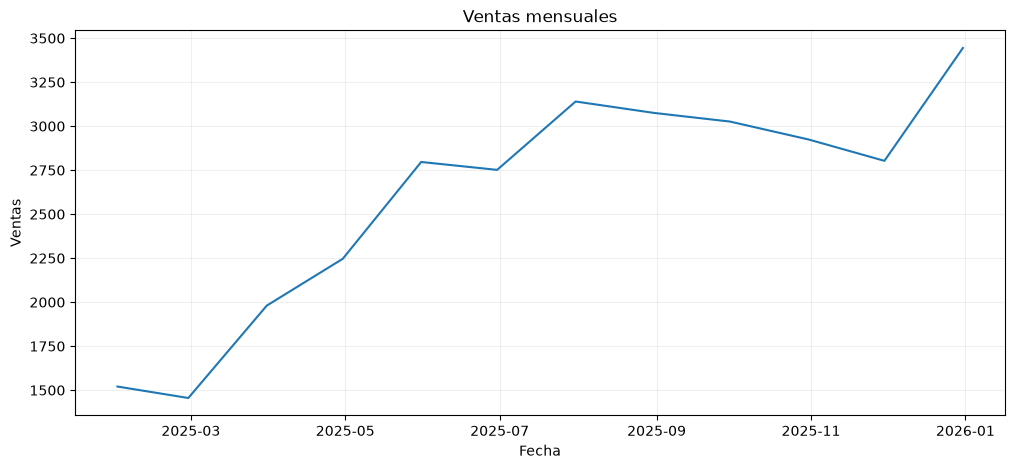

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(serie_mensual)
plt.title("Ventas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.2)
plt.show()

El resampling mensual ayuda a observar mejor el comportamiento general y evita parte del ruido de las observaciones diarias.


## Paso 5. Medias móviles MA7 y MA30

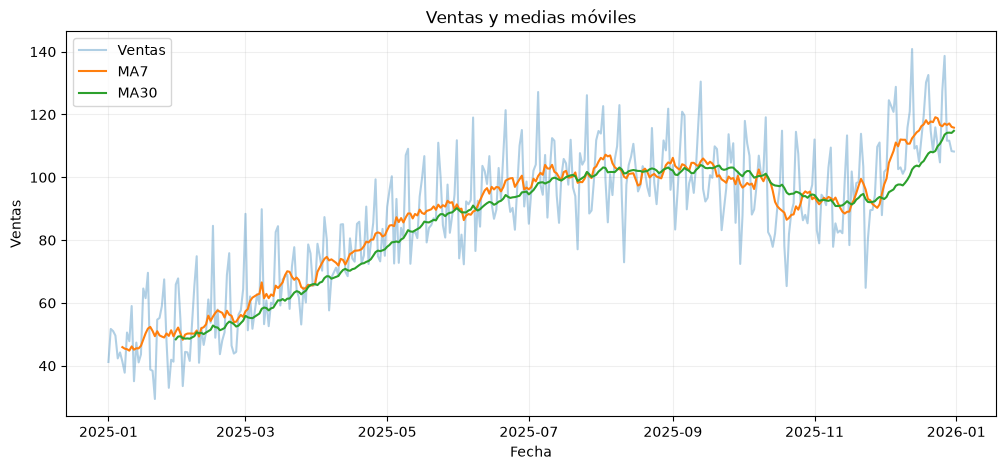

In [6]:
ma7 = serie.rolling(7).mean()
ma30 = serie.rolling(30).mean()

plt.figure(figsize=(12, 5))
plt.plot(serie, alpha=0.35, label="Ventas")
plt.plot(ma7, label="MA7")
plt.plot(ma30, label="MA30")
plt.title("Ventas y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Patrón semanal

In [15]:
ventas_dia = serie.groupby(serie.index.dayofweek).mean()
ventas_dia.index = ["Lunes", "Martes", "Miércoles", "Jueves","Viernes", "Sábado", "Domingo"]
display(ventas_dia)

Lunes         79.754615
Martes        80.700588
Miércoles     83.858846
Jueves        87.570204
Viernes       95.137885
Sábado       103.156275
Domingo       77.719808
Name: ventas, dtype: float64

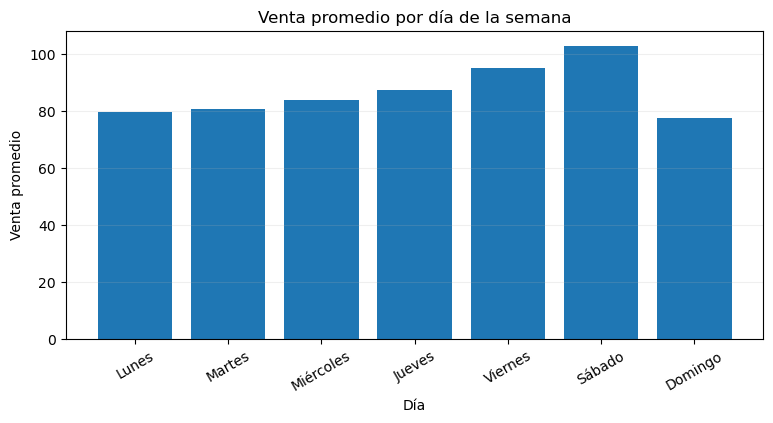

In [16]:
plt.figure(figsize=(9, 4))
plt.bar(ventas_dia.index, ventas_dia.values)
plt.title("Venta promedio por día de la semana")
plt.xlabel("Día")
plt.ylabel("Venta promedio")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.2)
plt.show()


Aquí podemos comparar si algunos días tienen ventas promedio claramente diferentes. Esto ayuda a evaluar la afirmación de que existe un patrón semanal.


## Paso 6 - Diferenciación

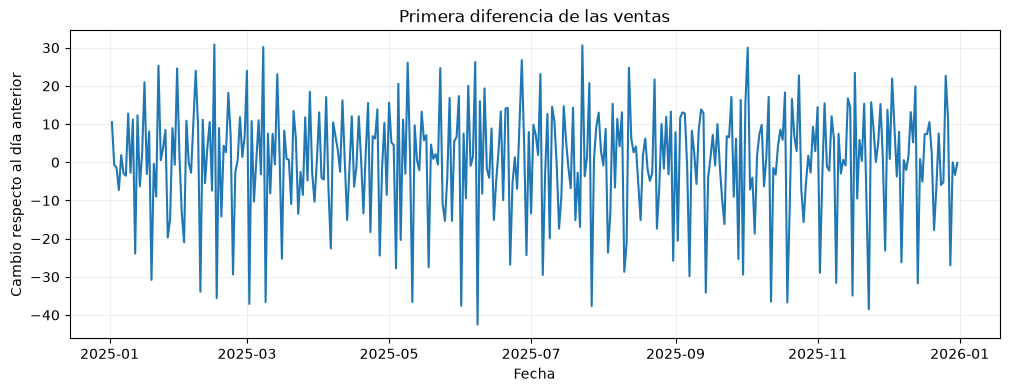

In [7]:
diferencia = serie.diff()

plt.figure(figsize=(12, 4))
plt.plot(diferencia)
plt.title("Primera diferencia de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Cambio respecto al día anterior")
plt.grid(alpha=0.2)
plt.show()

## Paso 7. Lags

In [18]:
for lag in [1, 7, 14, 30]:
    print(f"Lag {lag}: {serie.autocorr(lag):.4f}")

Lag 1: 0.7899
Lag 7: 0.8877
Lag 14: 0.8615
Lag 30: 0.5715


El lag 1 compara cada día con el día anterior. El lag 7 es especialmente importante porque permite revisar si existe una relación con el mismo día de la semana anterior.


## Paso8. Autocorrelación y ACF

In [8]:
print("Autocorrelación lag 1:", serie.autocorr(1))
print("Autocorrelación lag 7:", serie.autocorr(7))

Autocorrelación lag 1: 0.7898673412070166
Autocorrelación lag 7: 0.8877338872584083


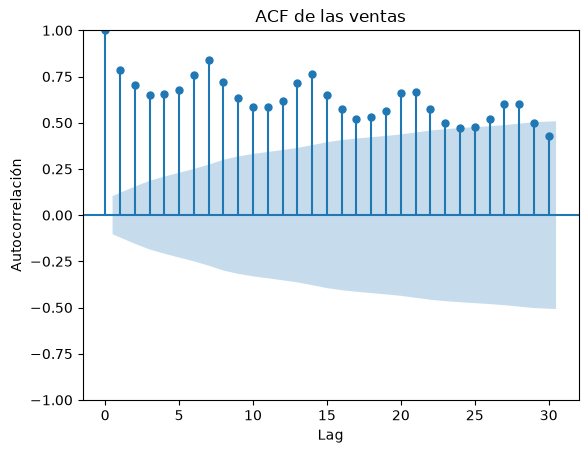

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(serie.dropna(), lags=30)
plt.title("ACF de las ventas")
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.show()

## Paso 9. Estacionalidad con ADF

In [21]:
from statsmodels.tsa.stattools import adfuller

adf_original = adfuller(serie.dropna())
adf_diferenciada = adfuller(diferencia.dropna())

print("ADF serie original")
print("Estadístico:", adf_original[0])
print("p-value:", adf_original[1])

print("\nADF serie diferenciada")
print("Estadístico:", adf_diferenciada[0])
print("p-value:", adf_diferenciada[1])

ADF serie original
Estadístico: -1.6194812418603213
p-value: 0.4730012734926608

ADF serie diferenciada
Estadístico: -9.704093101506162
p-value: 1.0531635926249655e-16


### Interpretación del ADF

La hipótesis nula de ADF es que existe raíz unitaria.

- Si `p < 0.05`, se rechaza H0.
- Si `p >= 0.05`, no se rechaza H0.

Esto permite comparar la serie original con la serie diferenciada.

# Preguntas de Reflexión

1. **¿Las ventas realmente tienen tendencia?**  
   Observé un crecimiento general durante el año: las ventas mensuales pasaron de 1,520.55 en enero a 3,444.17 en diciembre. Sin embargo, el aumento no fue constante, porque algunos meses presentaron disminuciones.  

2. **¿Existe evidencia de patrón semanal?**  
   Sí, encontré diferencias entre los promedios por día. El sábado tuvo el promedio más alto, con 103.16, seguido del viernes con 95.14; el domingo presentó el más bajo, con 77.72. Estos resultados sugieren un patrón semanal.  

3. **¿Qué lag tiene mayor relación con el presente?**  
   Entre los lags que analicé, el lag 7 presentó la autocorrelación más alta, con 0.8877, seguido del lag 14 con 0.8615. Sin embargo, como faltan seis fechas, estos lags representan observaciones y no siempre siete o catorce días exactos.  

4. **¿La serie original parece estacionaria?**  
   La prueba ADF obtuvo un p-value de 0.4730. Como es mayor que 0.05, no pude rechazar la hipótesis nula de raíz unitaria. Por lo tanto, esta prueba no aporta evidencia suficiente para considerar estacionaria la serie original.  




## Conclusión

En este análisis encontré que las ventas presentan un crecimiento general durante 2025, aunque con algunas disminuciones mensuales. También identifiqué un posible patrón semanal, con mayores ventas promedio los viernes y sábados. La prueba ADF no mostró evidencia suficiente de estacionariedad en la serie original, pero sí después de diferenciarla. Antes de utilizar estos resultados para construir un modelo de pronóstico, revisaría los seis días faltantes y regularizaría la frecuencia diaria para interpretar correctamente las medias móviles y los lags.